In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:
mps_df = pd.read_csv('./cache/mps_term10.csv')

In [3]:
mps_df.columns

Index(['id', 'firstName', 'lastName', 'birthDate', 'birthLocation',
       'educationLevel', 'profession', 'club', 'districtNum', 'districtName',
       'voivodeship', 'numberOfVotes', 'active', 'inactiveCause', 'waiverDesc',
       'percentOfVoting'],
      dtype='object')

# Liczba głosów

## Top 10 posłów pod względem otrzymanych głosów

In [4]:
mps_df[['firstName', 'lastName', 'club', 'numberOfVotes']].sort_values(by='numberOfVotes', ascending=False).head(10)

,firstName,lastName,club,numberOfVotes
399,Donald,Tusk,KO,538634
147,Jarosław,Kaczyński,PiS,177228
370,Adam,Szłapka,KO,149064
262,Barbara,Nowacka,KO,139524
99,Piotr,Gliński,PiS,135339
19,Mariusz,Błaszczak,PiS,127578
410,Małgorzata,Wassermann,PiS,125786
55,Przemysław,Czarnek,PiS,121686
245,Mateusz,Morawiecki,PiS,117064
226,Marlena,Maląg,PiS,109870


## Posłowie z największą ilością głosów per klub

In [5]:
max_numberOfVotes_in_club_series = mps_df.groupby('club')['numberOfVotes'].transform('max')
mps_with_max_numberOfVotes_in_club_series = mps_df[mps_df['numberOfVotes'] == max_numberOfVotes_in_club_series]
result_df = mps_with_max_numberOfVotes_in_club_series[['club', 'firstName', 'lastName', 'numberOfVotes']]

result_df.style

,club,firstName,lastName,numberOfVotes
105,niez.,Adam,Gomoła,21923
132,Polska2050-TD,Szymon,Hołownia,79951
147,PiS,Jarosław,Kaczyński,177228
173,PSL-TD,Władysław,Kosiniak-Kamysz,50139
199,Republikanie,Paweł,Kukiz,43292
240,Konfederacja,Sławomir,Mentzen,101269
272,Lewica,Dorota,Olko,44188
399,KO,Donald,Tusk,538634
441,Razem,Adrian,Zandberg,64435


## Posłowie z najmniejszą ilością głosów per klub

In [6]:
min_numberOfVotes_in_club_series = mps_df.groupby('club')['numberOfVotes'].transform('min')
mps_with_min_numberOfVotes_in_club_series = mps_df[mps_df['numberOfVotes'] == min_numberOfVotes_in_club_series]
result_df = mps_with_min_numberOfVotes_in_club_series[['club', 'firstName', 'lastName', 'numberOfVotes']]

result_df.style

,club,firstName,lastName,numberOfVotes
5,Republikanie,Jan,Ardanowski,28658
80,niez.,Roman,Fritz,11089
108,PiS,Mariusz,Gosek,5309
238,Razem,Paulina,Matysiak,17695
270,Polska2050-TD,Barbara,Okuła,3482
471,Lewica,Piotr,Kowal,7860
473,KO,Maria,Koźlakiewicz,4535
489,Konfederacja,Michał,Połuboczek,6287
492,PSL-TD,Henryk,Smolarz,5536


## Najniższa liczba głosów oddanych na posła per okręg wyborczy

In [7]:
mps_df.groupby('districtName').numberOfVotes.min().sort_values(ascending=False)

districtName
Nowy Sącz               12918
Krosno                  12184
Bielsko-Biała           11089
Sieradz                 10474
Piotrków Trybunalski    10426
Konin                   10304
Zielona Góra            10162
Olsztyn                  9837
Radom                    9755
Poznań                   9103
Legnica                  8527
Opole                    8322
Piła                     8263
Chełm                    8004
Toruń                    7860
Gdańsk                   7284
Wrocław                  7031
Łódź                     7018
Słupsk                   6379
Rzeszów                  6287
Warszawa                 6193
Szczecin                 6100
Katowice                 5996
Elbląg                   5979
Koszalin                 5700
Wałbrzych                5676
Lublin                   5536
Kielce                   5309
Kalisz                   5186
Tarnów                   5180
Częstochowa              5121
Siedlce                  5009
Kraków                   49

## Średnia liczba głosów oddanych na posła per klub

In [8]:
mps_df.groupby('club').numberOfVotes.mean().astype(int).sort_values(ascending=False)

club
Republikanie     36207
KO               29435
PiS              28123
Razem            27770
Konfederacja     24799
Polska2050-TD    24522
Lewica           24020
PSL-TD           21496
niez.            16067
Name: numberOfVotes, dtype: int32

# Obecna liczba posłów w klubach

In [9]:
mps_df_active = mps_df[mps_df.active == True]
mps_df_active.club.value_counts()

club
PiS              190
KO               157
PSL-TD            32
Polska2050-TD     32
Lewica            21
Konfederacja      16
Razem              5
Republikanie       4
niez.              3
Name: count, dtype: int64

<Axes: ylabel='count'>

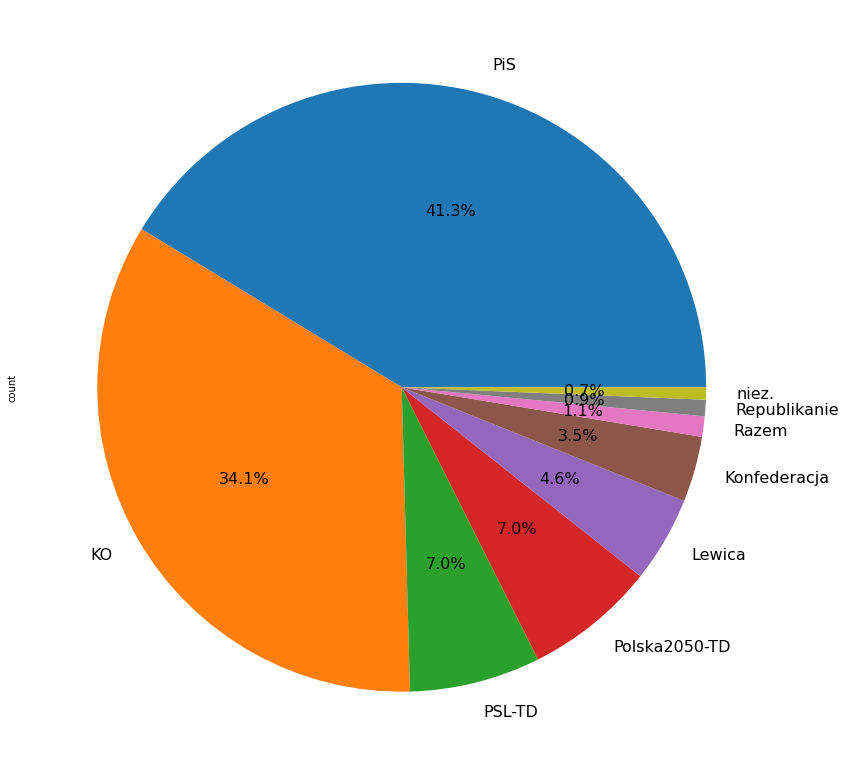

In [10]:
mps_df_active.club.value_counts().plot.pie(autopct='%1.1f%%', figsize=(16, 14), fontsize=16)

# Wykształcenie posłów

In [11]:
mps_df.educationLevel.value_counts()

educationLevel
wyższe                            469
średnie ogólne                     15
średnie policealne/pomaturalne      6
średnie zawodowe                    4
Name: count, dtype: int64

## Wykształcenie posłów per klub poselski

In [12]:
mps_df.groupby('club').educationLevel.value_counts()

club           educationLevel                
KO             wyższe                            168
               średnie ogólne                      6
               średnie zawodowe                    1
Konfederacja   wyższe                             16
               średnie ogólne                      2
Lewica         wyższe                             23
PSL-TD         wyższe                             33
PiS            wyższe                            190
               średnie policealne/pomaturalne      4
               średnie ogólne                      3
               średnie zawodowe                    3
Polska2050-TD  wyższe                             30
               średnie ogólne                      3
Razem          wyższe                              5
Republikanie   wyższe                              2
               średnie ogólne                      1
               średnie policealne/pomaturalne      1
niez.          wyższe                              2


# Analiza wieku posłów

In [13]:
now_date = pd.Timestamp(datetime.datetime.now())
mps_df.birthDate = pd.to_datetime(mps_df.birthDate)

# Calculate age
mps_df['age'] = now_date.year - mps_df.birthDate.dt.year

Wykres który przedstawiono poniżej to wykres typu boxplot. Zawiera on (patrząc od góry):
- wartość maksymalną
- trzeci kwartyl (25% danych ma wartość wyższą)
- mediana
- pierwszy kwartyl (25% danych ma wartość niższą)
- wartość minimalną
- kropki oznaczają outliery (obserwacje odstające, nieoczekiwane względem pozostałych danych)

<Axes: title={'center': 'age'}, xlabel='club'>

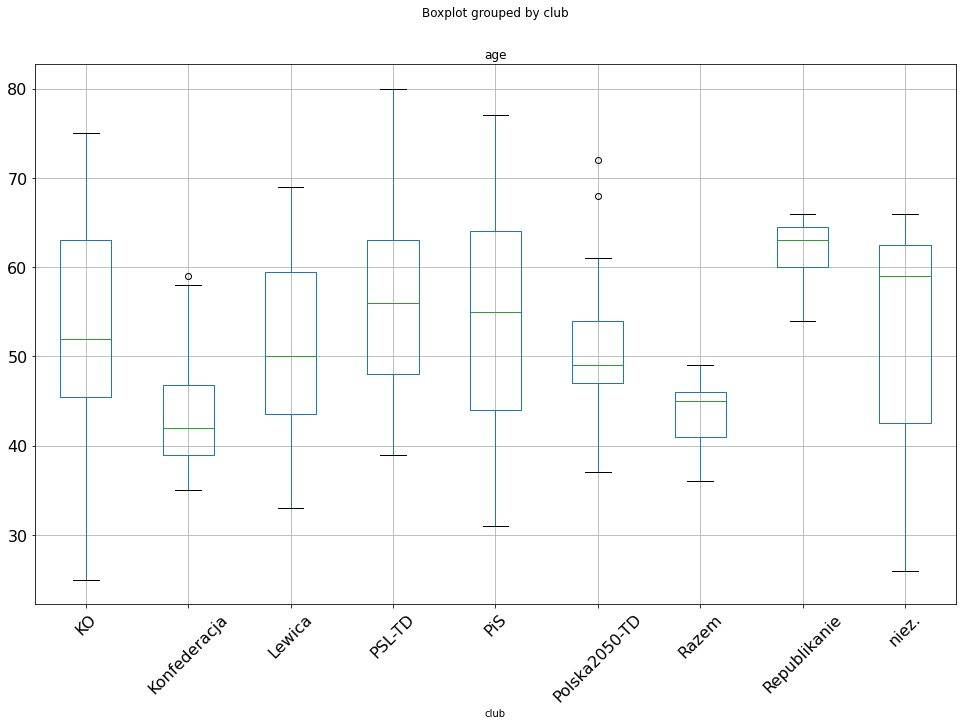

In [14]:
mps_df.boxplot(by='club', column='age', rot=45, figsize=(16, 10), fontsize=16)

## Procent średniej frekwencji na głosowaniach per klub

In [15]:
mps_df.groupby('club').percentOfVoting.mean()

club
KO               96.101771
Konfederacja     87.293889
Lewica           95.055217
PSL-TD           93.140909
PiS              91.066950
Polska2050-TD    93.116667
Razem            95.812000
Republikanie     84.090000
niez.            92.360000
Name: percentOfVoting, dtype: float64

## Posłowie z najniższą frekwencją na głosowaniach per klub

In [16]:
min_voting_in_club_series = mps_df.groupby('club')['percentOfVoting'].transform('min')
mps_with_min_voting_in_club = mps_df[mps_df['percentOfVoting'] == min_voting_in_club_series]
result_df = mps_with_min_voting_in_club[['club', 'firstName', 'lastName', 'percentOfVoting']]

result_df.style

,club,firstName,lastName,percentOfVoting
35,Polska2050-TD,Agnieszka,Buczyńska,68.260000
57,Lewica,Włodzimierz,Czarzasty,81.690000
80,niez.,Roman,Fritz,90.210000
142,KO,Danuta,Jazłowiecka,36.870000
199,Republikanie,Paweł,Kukiz,78.560000
334,PSL-TD,Czesław,Siekierski,74.920000
421,Konfederacja,Ryszard,Wilk,58.970000
444,Razem,Marcelina,Zawisza,92.920000
455,PiS,Zbigniew,Ziobro,12.260000


## Dystrybuanta frekwencji na głosowaniach

Wykres określa jaki procent posłów ma niższą frekwencję od wartości w danym punkcie.

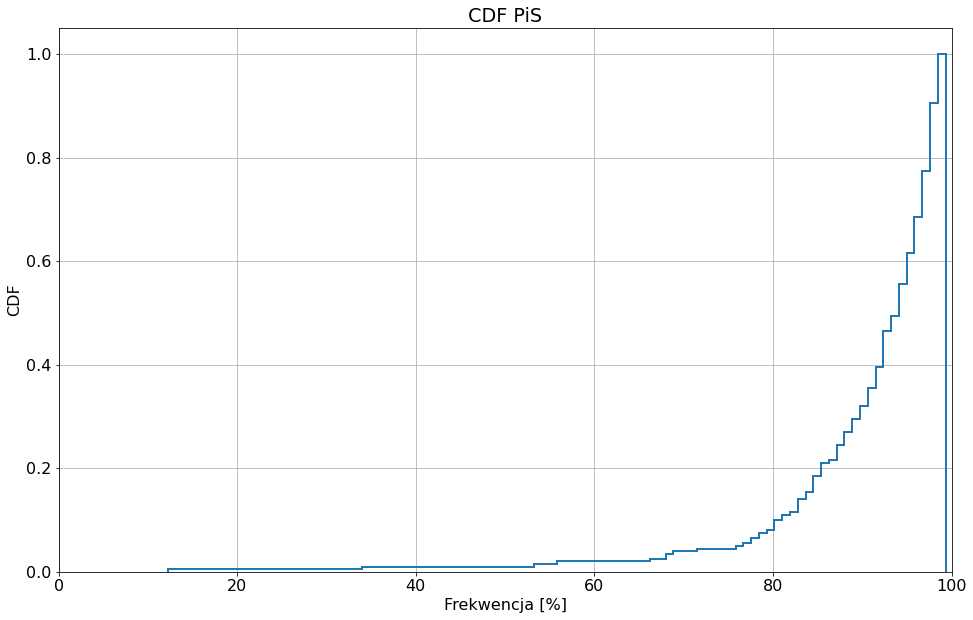

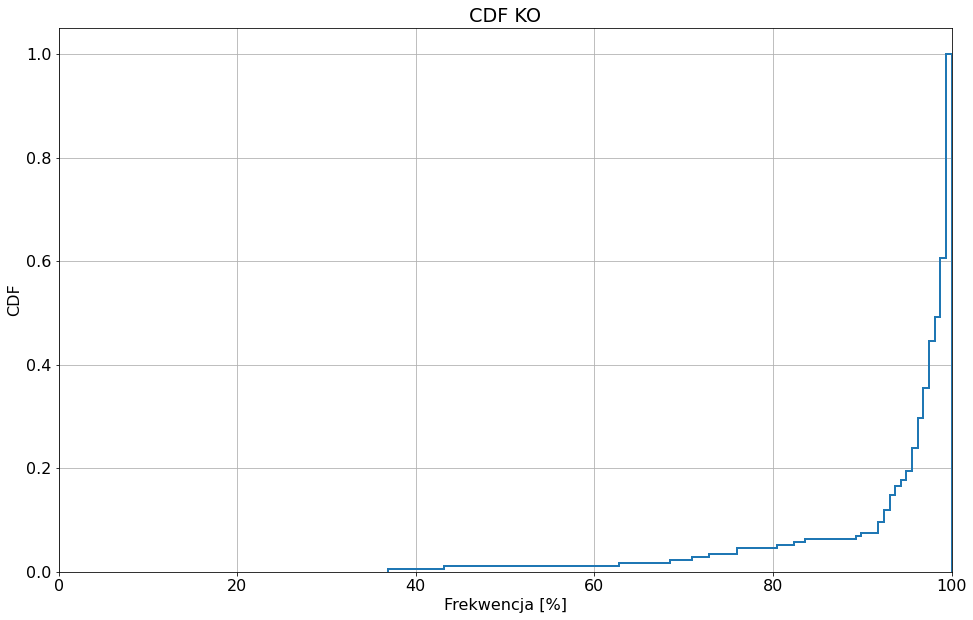

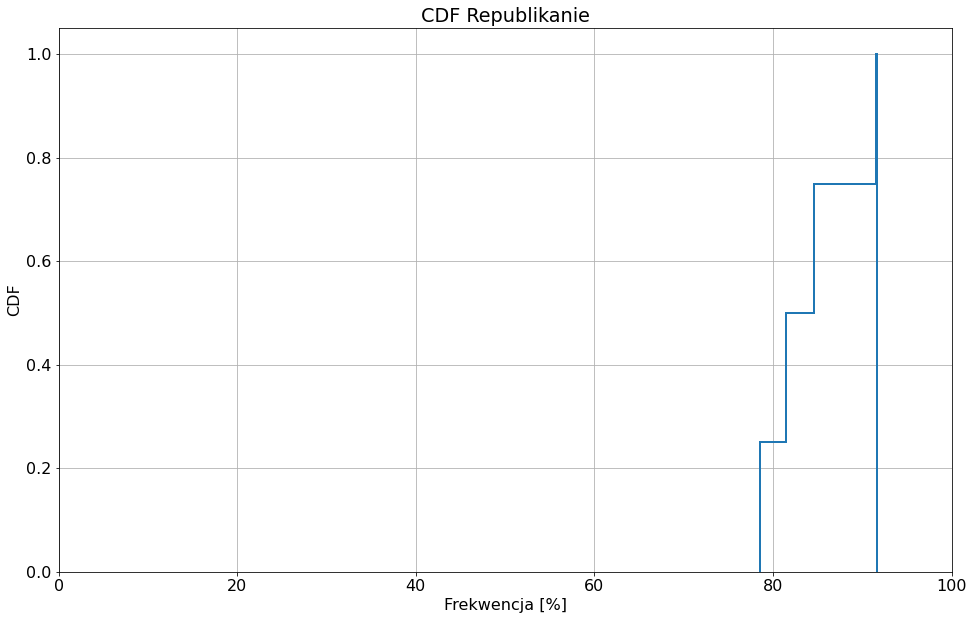

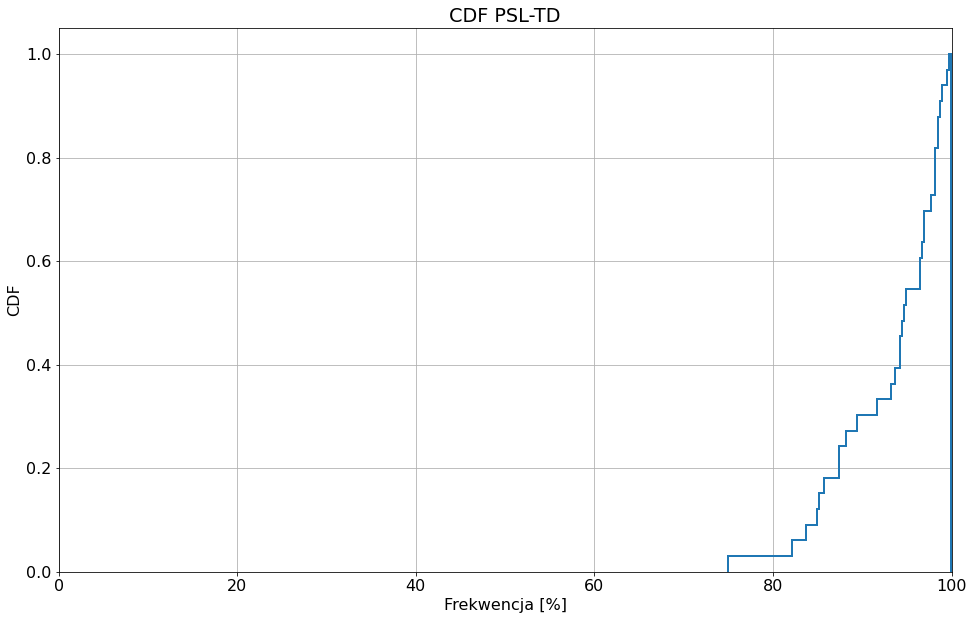

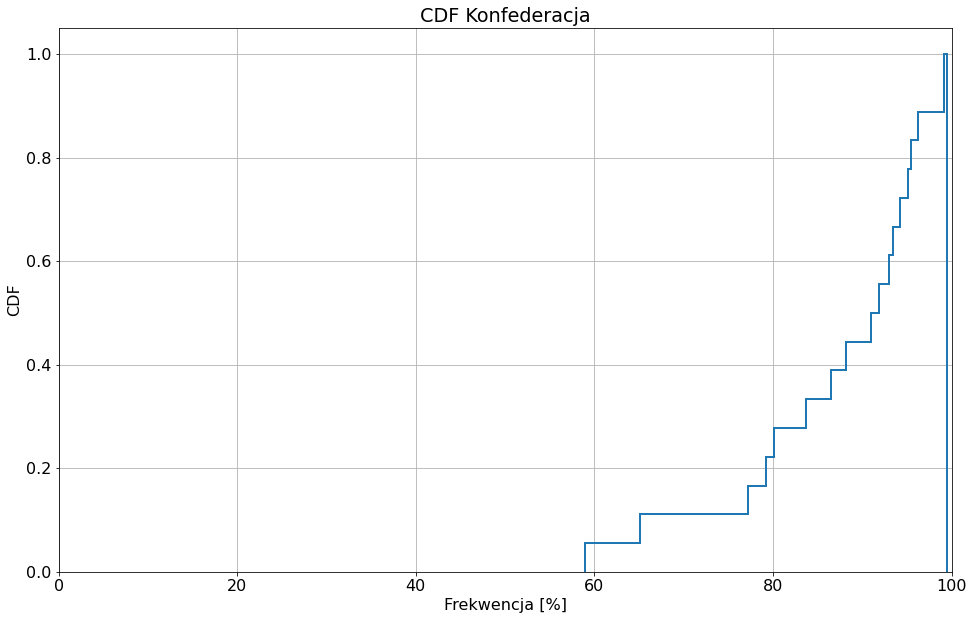

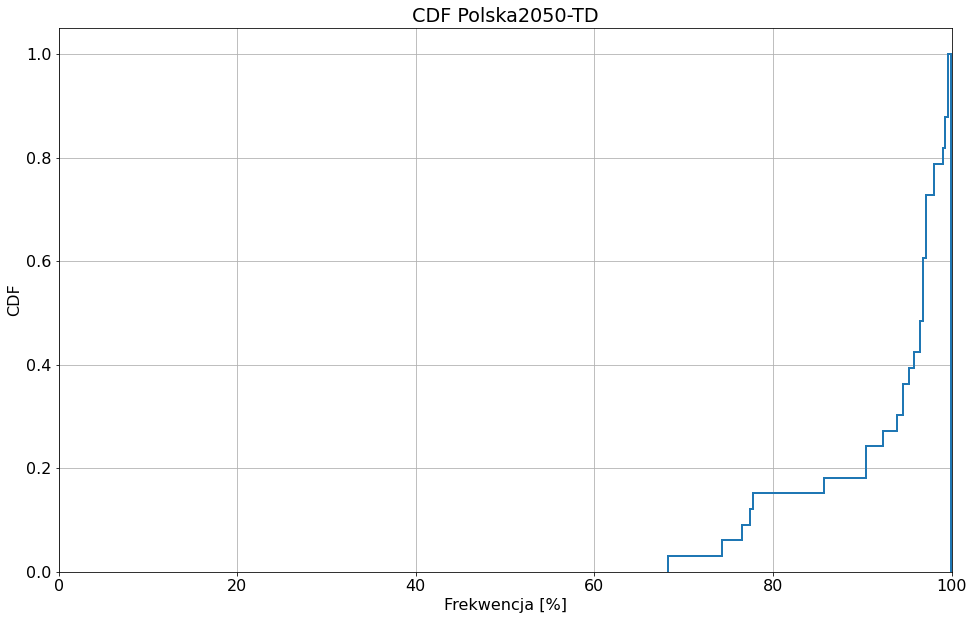

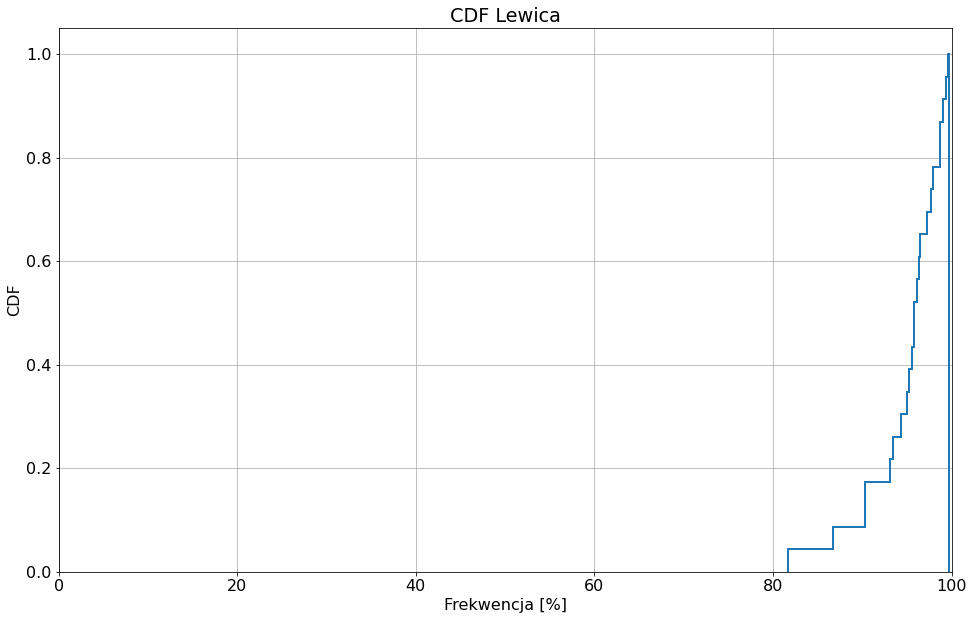

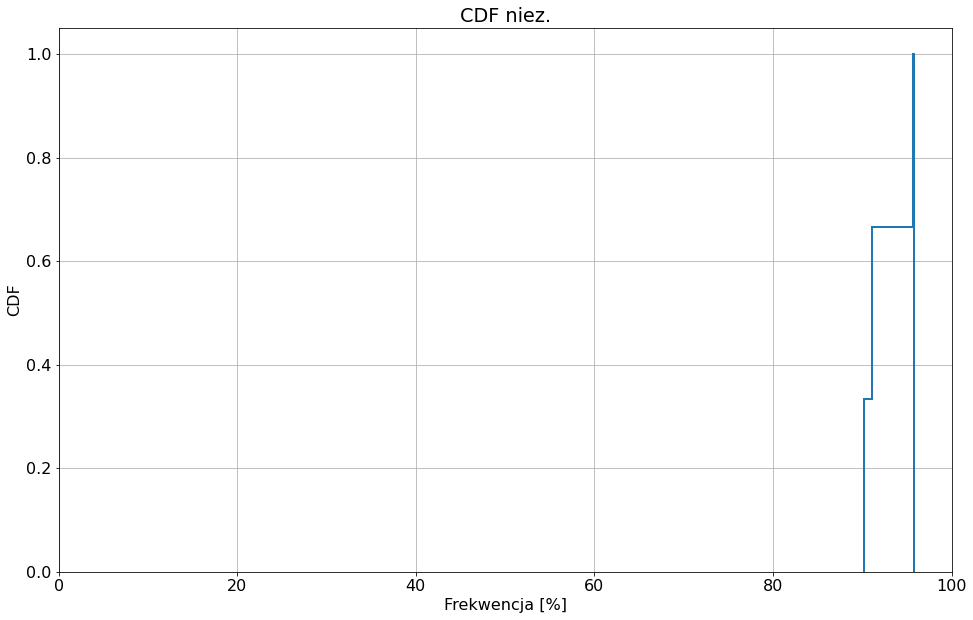

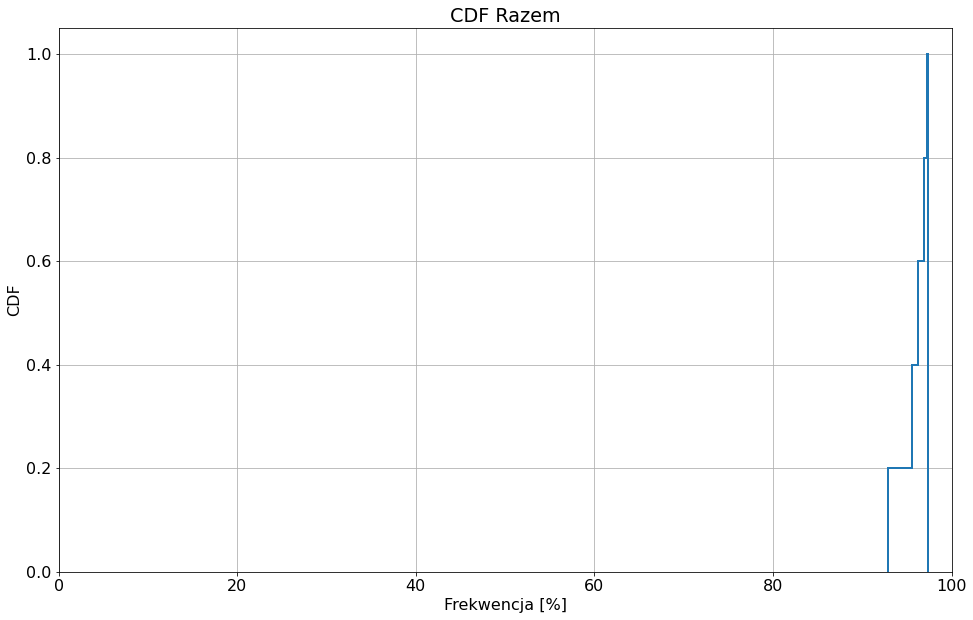

In [17]:
for club in mps_df.club.unique():
    plt.figure(figsize=(16,10))
    plt.rcParams.update(
        {'font.size': 16}
    )
    plt.hist(
        mps_df[mps_df.club == club].percentOfVoting,
        bins=100,
        cumulative=True,
        density=True,
        histtype='step',
        linewidth=2
    )
    plt.xlim(0,100)
    plt.grid(True)
    plt.title(f'CDF {club}')
    plt.xlabel('Frekwencja [%]')
    plt.ylabel('CDF')
    plt.show()